<a href="https://colab.research.google.com/github/Pranayshukla0610/Financial-Analyst/blob/main/Real_Time_Fixed_Income_Analytics_%26_Treasury_Yield_Forecasting_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install fredapi

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from fredapi import Fred

In [6]:
fred = Fred(api_key='166926f1bb8319cfc9d8ac5de3d41029')

In [7]:
treasury_3m = fred.get_series('DTB3')
treasury_2y = fred.get_series('DGS2')
treasury_10y = fred.get_series('DGS10')
treasury_30y = fred.get_series('DGS30')

In [8]:
df = pd.DataFrame({
    '3M_Yield':treasury_3m,
    '2Y_Yield':treasury_2y,
    '10Y_Yield':treasury_10y,
    '30Y_Yield':treasury_30y
})

In [9]:
df.head()

,3M_Yield,2Y_Yield,10Y_Yield,30Y_Yield
1954-01-04,1.33,NaN,NaN,NaN
1954-01-05,1.28,NaN,NaN,NaN
1954-01-06,1.28,NaN,NaN,NaN
1954-01-07,1.31,NaN,NaN,NaN
1954-01-08,1.31,NaN,NaN,NaN


In [10]:
df = df.dropna()

In [11]:
df.head()

,3M_Yield,2Y_Yield,10Y_Yield,30Y_Yield
1977-02-15,4.63,6.04,7.36,7.70
1977-02-16,4.62,6.02,7.34,7.67
1977-02-17,4.61,5.99,7.26,7.67
1977-02-18,4.66,6.06,7.41,7.76
1977-02-22,4.69,6.09,7.42,7.77


In [13]:
latest = df.iloc[-1]

yield_curve = pd.DataFrame({
    'Maturity':['3M','2Y','10Y','30Y'],
    'Yield':latest.values
})

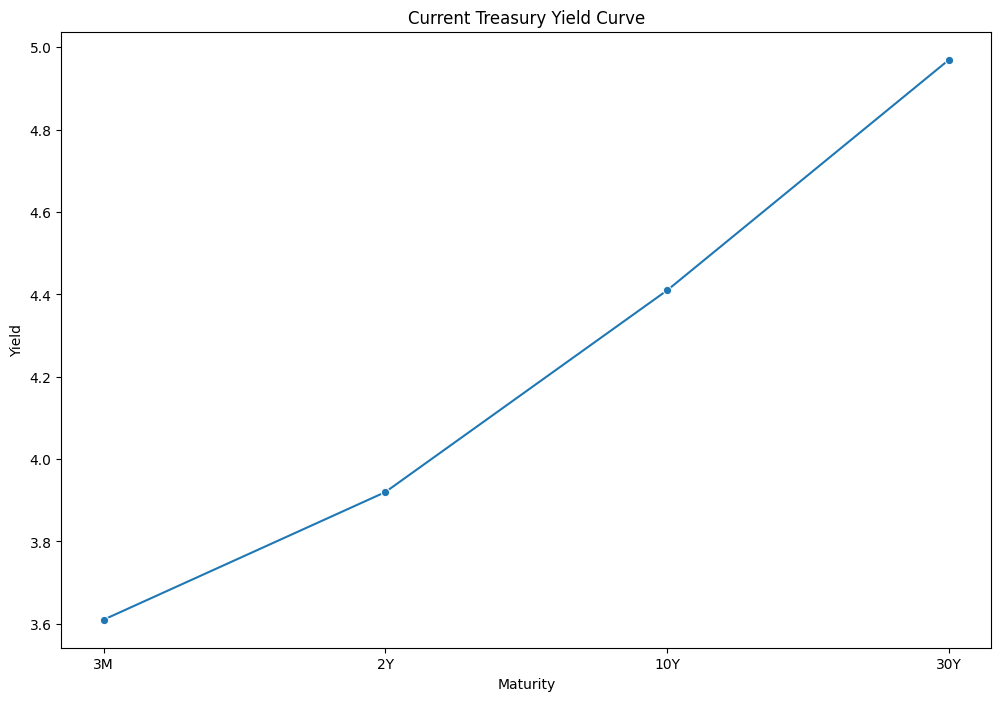

In [14]:
plt.figure(figsize=(12,8))
sns.lineplot(x='Maturity',
             y='Yield',
             data = yield_curve,
             marker='o')

plt.title('Current Treasury Yield Curve')
plt.xlabel('Maturity')
plt.ylabel('Yield')
plt.show()

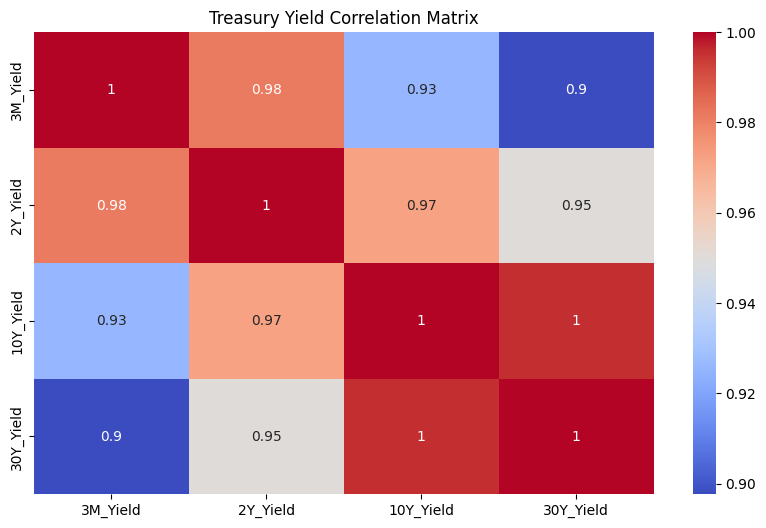

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),
            annot = True,
            cmap='coolwarm')

plt.title('Treasury Yield Correlation Matrix')
plt.show()

In [16]:
#Rolling Volatility

df['10Y_volatility'] = (
    df['10Y_Yield'].rolling(30).std()
)

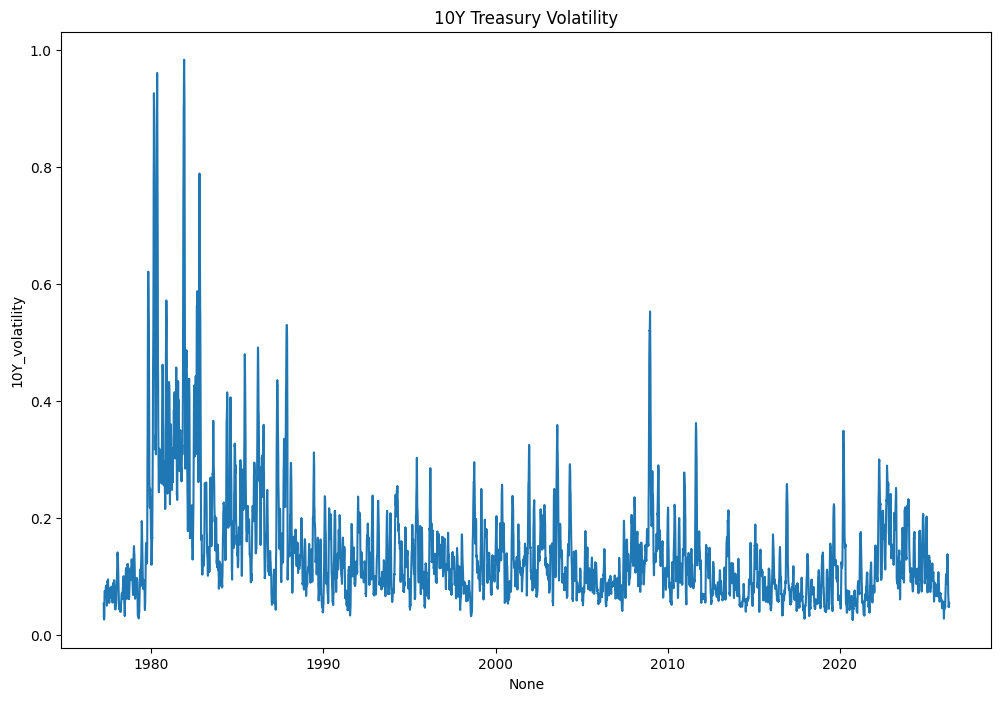

In [20]:
plt.figure(figsize=(12,8))

sns.lineplot(
    x=df.index,
    y=df['10Y_volatility']
)

plt.title('10Y Treasury Volatility')
plt.show()

In [21]:
#BOND DURATION ANALYTICS

df['Duration'] = 10 / (1 + df['10Y_Yield']/100)

In [22]:
df.head()

,3M_Yield,2Y_Yield,10Y_Yield,30Y_Yield,10Y_volatility,Duration
1977-02-15,4.63,6.04,7.36,7.70,NaN,9.314456
1977-02-16,4.62,6.02,7.34,7.67,NaN,9.316192
1977-02-17,4.61,5.99,7.26,7.67,NaN,9.323140
1977-02-18,4.66,6.06,7.41,7.76,NaN,9.310120
1977-02-22,4.69,6.09,7.42,7.77,NaN,9.309253


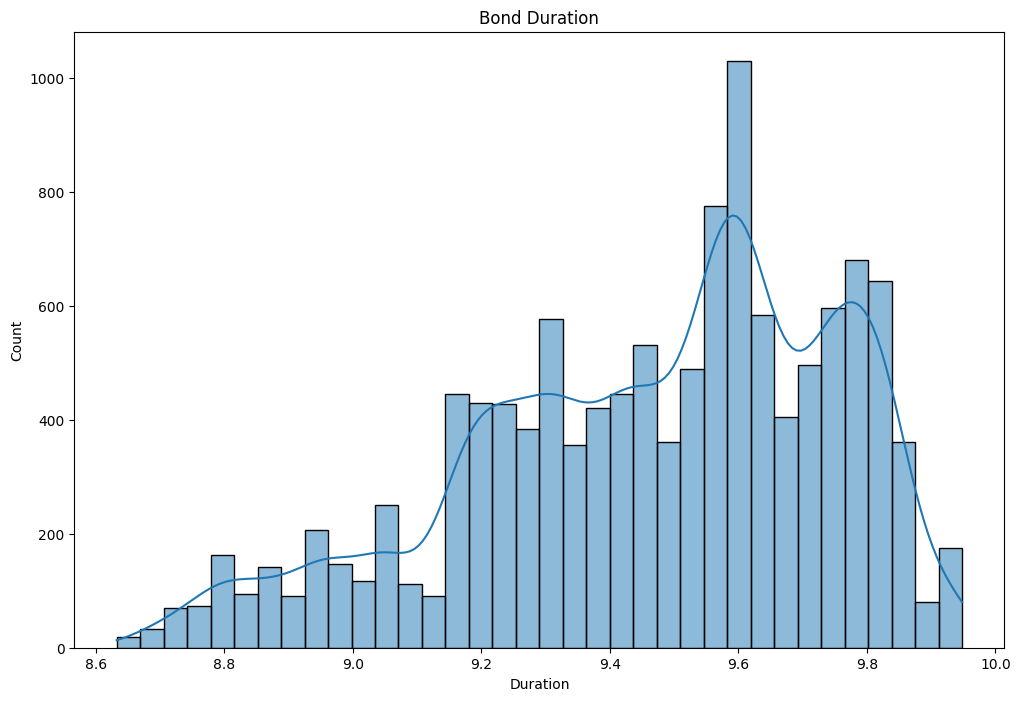

In [23]:
plt.figure(figsize=(12,8))

sns.histplot(
    df['Duration'],
    kde = True
)

plt.title('Bond Duration')
plt.show()

In [24]:
df['Spread_10Y_2Y'] = (
    df['10Y_Yield'] - df['2Y_Yield']
)

df['Spread_30Y_10Y'] = (
    df['30Y_Yield'] - df['10Y_Yield']
)

In [25]:
df['Lag_1'] = df['10Y_Yield'].shift(1)
df['Lag_7'] = df['10Y_Yield'].shift(7)
df['Lag_30'] = df['10Y_Yield'].shift(30)

In [26]:
df.head()

,3M_Yield,2Y_Yield,10Y_Yield,30Y_Yield,10Y_volatility,Duration,Spread_10Y_2Y,Spread_30Y_10Y,Lag_1,Lag_7,Lag_30
1977-02-15,4.63,6.04,7.36,7.70,NaN,9.314456,1.32,0.34,NaN,NaN,NaN
1977-02-16,4.62,6.02,7.34,7.67,NaN,9.316192,1.32,0.33,7.36,NaN,NaN
1977-02-17,4.61,5.99,7.26,7.67,NaN,9.323140,1.27,0.41,7.34,NaN,NaN
1977-02-18,4.66,6.06,7.41,7.76,NaN,9.310120,1.35,0.35,7.26,NaN,NaN
1977-02-22,4.69,6.09,7.42,7.77,NaN,9.309253,1.33,0.35,7.41,NaN,NaN


In [27]:
df = df.dropna()

In [28]:
features = [
    '3M_Yield',
    '2Y_Yield',
    '30Y_Yield',
    'Spread_10Y_2Y',
    'Spread_30Y_10Y',
    'Lag_1',
    'Lag_7',
    'Lag_30'
]

X = df[features]

y = df['10Y_Yield']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [30]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [31]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [32]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [33]:
def evaluate_model(y_true, pred, name):

    print(f"\n{name}")

    print("MAE:",
          mean_absolute_error(y_true, pred))

    print("RMSE:",
          np.sqrt(mean_squared_error(y_true, pred)))

    print("R2 Score:",
          r2_score(y_true, pred))

In [34]:
evaluate_model(y_test, lr_pred, "Linear Regression")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, xgb_pred, "XGBoost")


Linear Regression
MAE: 1.439400759706481e-15
RMSE: 1.699837957668146e-15
R2 Score: 1.0

Random Forest
MAE: 0.12200581303862583
RMSE: 0.2186547828137237
R2 Score: 0.9666694158159739

XGBoost
MAE: 0.1067424608024706
RMSE: 0.2150065034694667
R2 Score: 0.9677723858173194


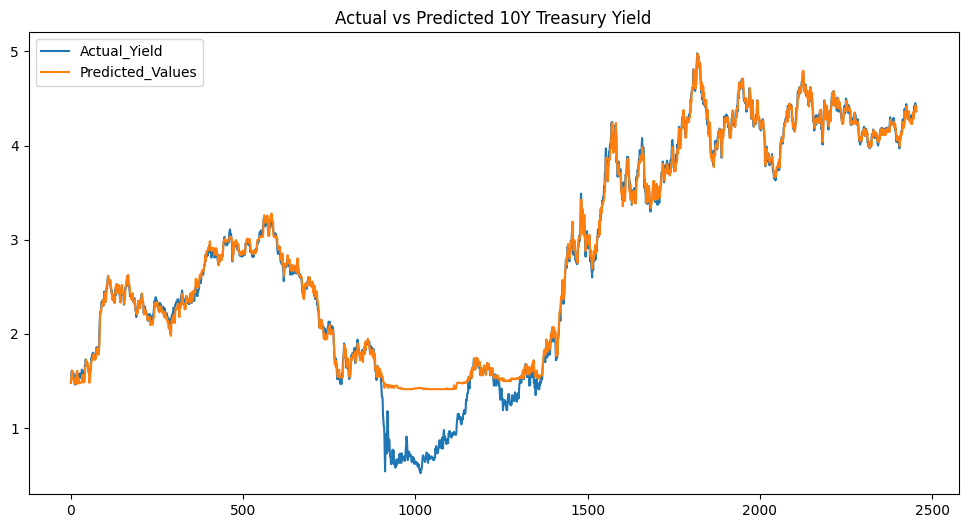

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual_Yield'
)

plt.plot(
    xgb_pred,
    label = 'Predicted_Values'
)

plt.legend()
plt.title('Actual vs Predicted 10Y Treasury Yield')
plt.show()

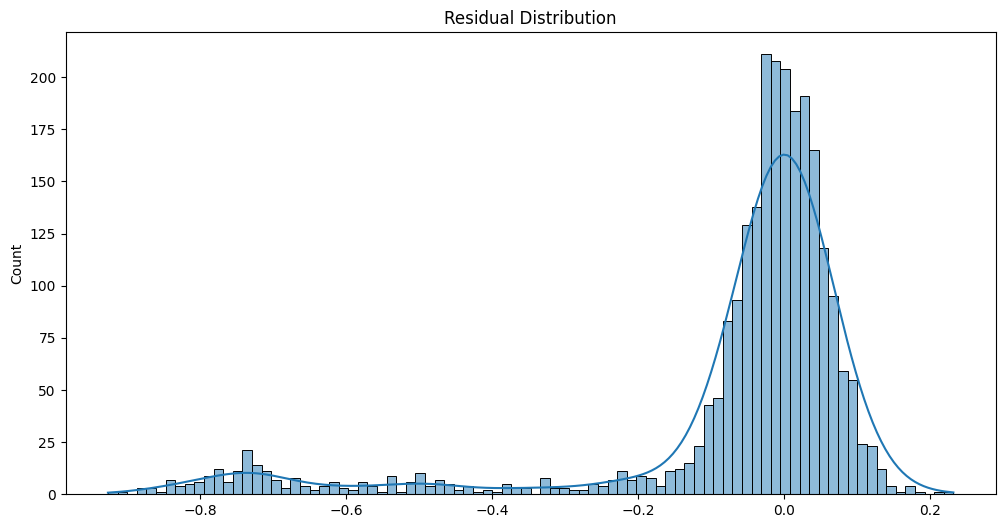

In [36]:
residuals = y_test.values - xgb_pred

plt.figure(figsize=(12,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title('Residual Distribution')

plt.show()

In [37]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

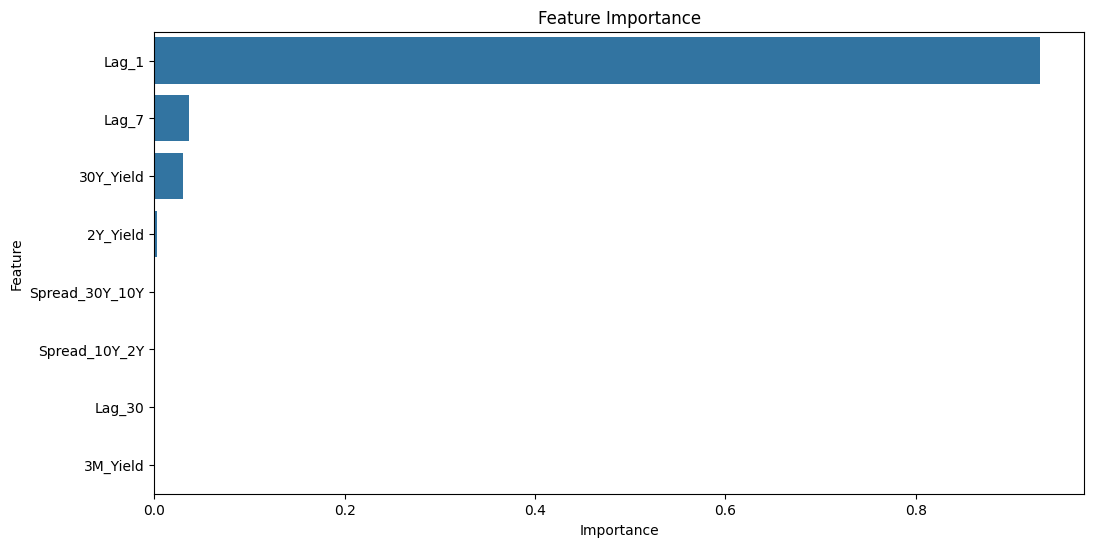

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

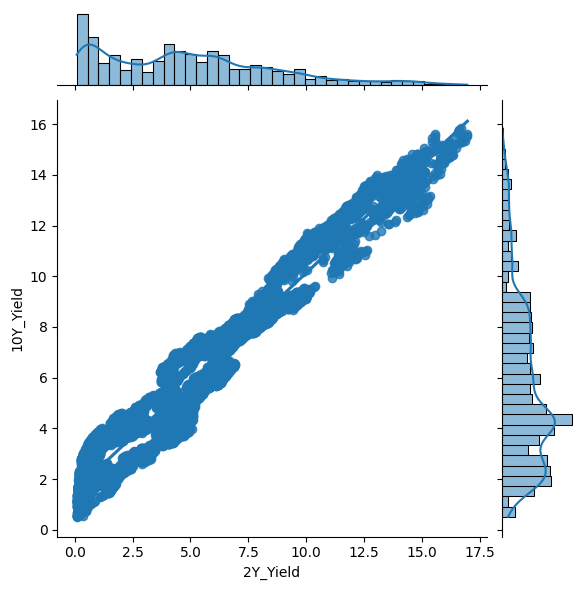

In [39]:
sns.jointplot(
    x='2Y_Yield',
    y='10Y_Yield',
    data=df,
    kind='reg'
)

plt.show()

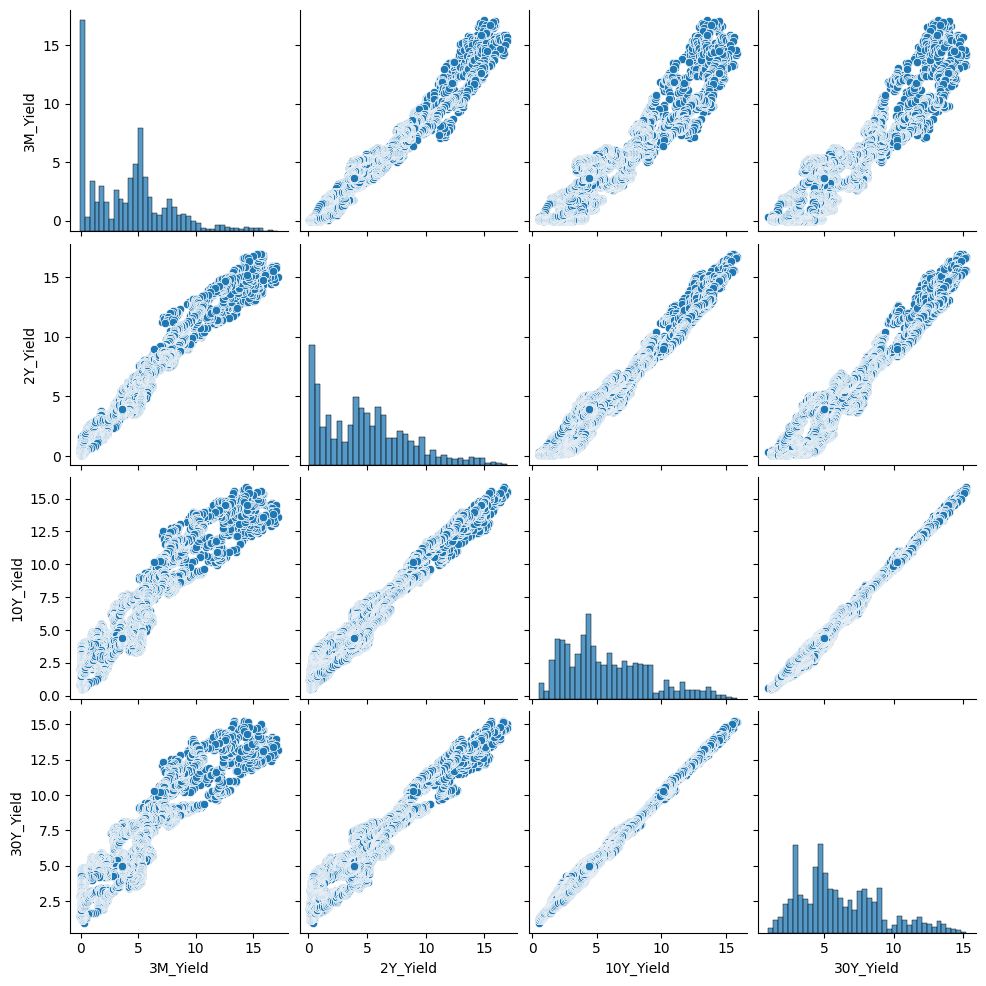

In [40]:
sns.pairplot(df[
    [
        '3M_Yield',
        '2Y_Yield',
        '10Y_Yield',
        '30Y_Yield'
    ]
])

plt.show()

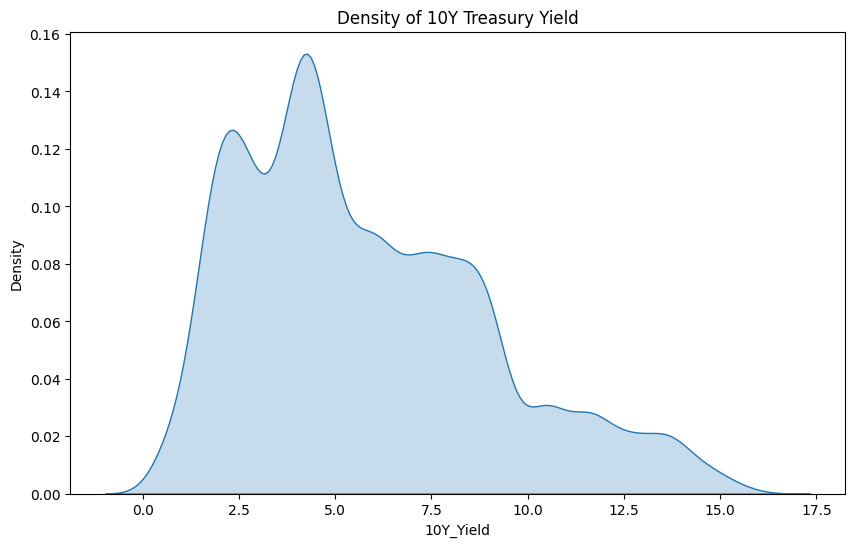

In [41]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['10Y_Yield'],
    fill=True
)

plt.title('Density of 10Y Treasury Yield')

plt.show()

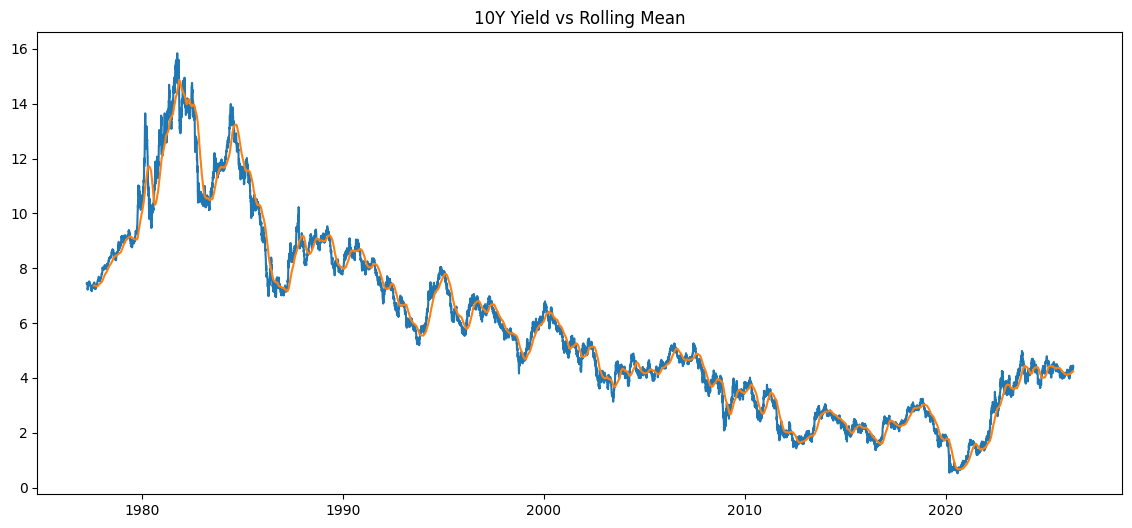

In [43]:
df['Rolling_90D'] = (
    df['10Y_Yield']
    .rolling(90)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(df['10Y_Yield'])

plt.plot(df['Rolling_90D'])

plt.title('10Y Yield vs Rolling Mean')

plt.show()